# Writer-Disjoint Baseline Verification

This notebook evaluates writer-verification performance on unseen QUWI writers using the fixed exhaustive protocol created previously.

## Evaluation models

1. ImageNet-pretrained ResNet-18 encoder
2. Controlled layer-4 fine-tuned ResNet-18 encoder

The frozen linear-probe classifier from the previous experiment is not treated as a separate embedding model because its ResNet-18 backbone was never updated. Its embeddings are therefore identical to those of the original ImageNet-pretrained encoder.

## Protocol

- Model development writers: 226
- Writer-disjoint validation writers: 56
- Writer-disjoint official-test writers: 193
- Verification conditions: 6
- Validation pairs: 18,816
- Official-test pairs: 223,494

Each handwriting image will be encoded once into a 512-dimensional feature vector. Pair scores will then be computed using cosine similarity between L2-normalized embeddings.

## Goals

- Extract and cache embeddings for unseen validation and official-test writers
- Compare frozen and fine-tuned ResNet-18 representations
- Score all genuine and impostor verification pairs
- Measure ROC-AUC and equal error rate
- Compare within-script and cross-script performance
- Analyze genuine and impostor score distributions
- Keep official-test evaluation separate from later threshold selection

In [2]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve
from torch import nn
from torch.utils.data import DataLoader
from torchvision.models import ResNet18_Weights, resnet18

from handwriting_cross_script_research import QUWIDataset

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (
    PROJECT_ROOT / "pyproject.toml"
).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "pyproject.toml").exists()

IMAGE_DIR = (
    Path.home()
    / "Documents"
    / "Handwriting"
    / "QUWI"
    / "extracted"
    / "images"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "splits"
    / "quwi_writer_disjoint_split_seed42.csv"
)

VALIDATION_PAIR_PATH = (
    PROJECT_ROOT
    / "splits"
    / "verification"
    / "quwi_validation_verification_pairs.csv"
)

TEST_PAIR_PATH = (
    PROJECT_ROOT
    / "splits"
    / "verification"
    / "quwi_official_test_verification_pairs.csv"
)

FINETUNED_CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "supervised_finetuning"
    / "resnet18_layer4_finetuning_best.pt"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "writer_disjoint_baseline_verification"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Project root:", PROJECT_ROOT)
print("Image directory exists:", IMAGE_DIR.exists())
print("Split file exists:", SPLIT_PATH.exists())
print("Validation pairs exist:", VALIDATION_PAIR_PATH.exists())
print("Official-test pairs exist:", TEST_PAIR_PATH.exists())
print("Fine-tuned checkpoint exists:", FINETUNED_CHECKPOINT_PATH.exists())
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Project root: /home/arijit/Documents/handwriting-cross-script-research
Image directory exists: True
Split file exists: True
Validation pairs exist: True
Official-test pairs exist: True
Fine-tuned checkpoint exists: True
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
split_df = pd.read_csv(SPLIT_PATH)

validation_metadata_df = split_df[
    split_df["experiment_split"] == "validation"
].copy()

test_metadata_df = split_df[
    split_df["experiment_split"] == "official_test"
].copy()

validation_pairs_df = pd.read_csv(
    VALIDATION_PAIR_PATH
)

test_pairs_df = pd.read_csv(
    TEST_PAIR_PATH
)

print(
    "Validation images:",
    len(validation_metadata_df),
)

print(
    "Validation writers:",
    validation_metadata_df["writer"].nunique(),
)

print(
    "Official-test images:",
    len(test_metadata_df),
)

print(
    "Official-test writers:",
    test_metadata_df["writer"].nunique(),
)

print(
    "Validation pairs:",
    len(validation_pairs_df),
)

print(
    "Official-test pairs:",
    len(test_pairs_df),
)

print(
    "Validation conditions:",
    validation_pairs_df["condition_id"].nunique(),
)

print(
    "Official-test conditions:",
    test_pairs_df["condition_id"].nunique(),
)

print(
    "Validation genuine/impostor:",
    validation_pairs_df["pair_label"].value_counts().sort_index().to_dict(),
)

print(
    "Official-test genuine/impostor:",
    test_pairs_df["pair_label"].value_counts().sort_index().to_dict(),
)

assert len(validation_metadata_df) == 224
assert validation_metadata_df["writer"].nunique() == 56
assert len(test_metadata_df) == 772
assert test_metadata_df["writer"].nunique() == 193
assert len(validation_pairs_df) == 18_816
assert len(test_pairs_df) == 223_494
assert validation_pairs_df["condition_id"].nunique() == 6
assert test_pairs_df["condition_id"].nunique() == 6

Validation images: 224
Validation writers: 56
Official-test images: 772
Official-test writers: 193
Validation pairs: 18816
Official-test pairs: 223494
Validation conditions: 6
Official-test conditions: 6
Validation genuine/impostor: {0: 18480, 1: 336}
Official-test genuine/impostor: {0: 222336, 1: 1158}


In [5]:
BATCH_SIZE = 16
NUM_WORKERS = 0

validation_dataset = QUWIDataset(
    metadata=validation_metadata_df,
    image_dir=IMAGE_DIR,
)

test_dataset = QUWIDataset(
    metadata=test_metadata_df,
    image_dir=IMAGE_DIR,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

validation_batch = next(iter(validation_loader))
test_batch = next(iter(test_loader))

print(
    "Dataset sizes:",
    {
        "validation": len(validation_dataset),
        "official_test": len(test_dataset),
    },
)

print(
    "Loader batches:",
    {
        "validation": len(validation_loader),
        "official_test": len(test_loader),
    },
)

print(
    "Validation batch shape:",
    validation_batch["image"].shape,
)

print(
    "Test batch shape:",
    test_batch["image"].shape,
)

print(
    "Validation filenames:",
    validation_batch["filename"][:4],
)

print(
    "Test filenames:",
    test_batch["filename"][:4],
)

assert len(validation_dataset) == 224
assert len(test_dataset) == 772
assert validation_batch["image"].shape == (16, 3, 384, 384)
assert test_batch["image"].shape == (16, 3, 384, 384)

Dataset sizes: {'validation': 224, 'official_test': 772}
Loader batches: {'validation': 14, 'official_test': 49}
Validation batch shape: torch.Size([16, 3, 384, 384])
Test batch shape: torch.Size([16, 3, 384, 384])
Validation filenames: ['0004_1.jpg', '0004_2.jpg', '0004_3.jpg', '0004_4.jpg']
Test filenames: ['0283_1.jpg', '0283_2.jpg', '0283_3.jpg', '0283_4.jpg']


In [6]:
NUM_CLASSES = 226

IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406,
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225,
)


class VerificationWriterModel(nn.Module):
    def __init__(
        self,
        num_classes,
        weights=None,
    ):
        super().__init__()

        backbone = resnet18(
            weights=weights
        )

        feature_dimension = (
            backbone.fc.in_features
        )

        backbone.fc = nn.Identity()

        self.feature_extractor = backbone

        self.classifier = nn.Linear(
            feature_dimension,
            num_classes,
        )

        self.register_buffer(
            "normalization_mean",
            torch.tensor(
                IMAGENET_MEAN
            ).view(1, 3, 1, 1),
        )

        self.register_buffer(
            "normalization_std",
            torch.tensor(
                IMAGENET_STD
            ).view(1, 3, 1, 1),
        )

    def extract_embeddings(
        self,
        images,
    ):
        images = (
            images
            - self.normalization_mean
        ) / self.normalization_std

        features = self.feature_extractor(
            images
        )

        embeddings = F.normalize(
            features,
            p=2,
            dim=1,
        )

        return embeddings

    def forward(self, images):
        embeddings = self.extract_embeddings(
            images
        )

        return self.classifier(
            embeddings
        )


imagenet_model = VerificationWriterModel(
    num_classes=NUM_CLASSES,
    weights=ResNet18_Weights.DEFAULT,
).to(DEVICE)

finetuned_model = VerificationWriterModel(
    num_classes=NUM_CLASSES,
    weights=None,
)

finetuned_checkpoint = torch.load(
    FINETUNED_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

finetuned_model.load_state_dict(
    finetuned_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

finetuned_model = finetuned_model.to(
    DEVICE
)

imagenet_model.eval()
finetuned_model.eval()

sample_images = validation_batch[
    "image"
].to(
    DEVICE,
    non_blocking=True,
)

with torch.inference_mode():
    imagenet_embeddings = (
        imagenet_model.extract_embeddings(
            sample_images
        )
    )

    finetuned_embeddings = (
        finetuned_model.extract_embeddings(
            sample_images
        )
    )

print(
    "Fine-tuned checkpoint epoch:",
    finetuned_checkpoint["epoch"],
)

print(
    "ImageNet embedding shape:",
    imagenet_embeddings.shape,
)

print(
    "Fine-tuned embedding shape:",
    finetuned_embeddings.shape,
)

print(
    "ImageNet mean L2 norm:",
    imagenet_embeddings.norm(
        dim=1
    ).mean().item(),
)

print(
    "Fine-tuned mean L2 norm:",
    finetuned_embeddings.norm(
        dim=1
    ).mean().item(),
)

print(
    "Finite ImageNet embeddings:",
    torch.isfinite(
        imagenet_embeddings
    ).all().item(),
)

print(
    "Finite fine-tuned embeddings:",
    torch.isfinite(
        finetuned_embeddings
    ).all().item(),
)

assert finetuned_checkpoint["epoch"] == 3
assert imagenet_embeddings.shape == (16, 512)
assert finetuned_embeddings.shape == (16, 512)
assert torch.allclose(
    imagenet_embeddings.norm(dim=1),
    torch.ones(16, device=DEVICE),
    atol=1e-5,
)
assert torch.allclose(
    finetuned_embeddings.norm(dim=1),
    torch.ones(16, device=DEVICE),
    atol=1e-5,
)

Fine-tuned checkpoint epoch: 3
ImageNet embedding shape: torch.Size([16, 512])
Fine-tuned embedding shape: torch.Size([16, 512])
ImageNet mean L2 norm: 1.0
Fine-tuned mean L2 norm: 1.0
Finite ImageNet embeddings: True
Finite fine-tuned embeddings: True


In [7]:
@torch.inference_mode()
def extract_dataset_embeddings(
    model,
    loader,
    device,
):
    model.eval()

    filenames = []
    writer_ids = []
    page_ids = []
    languages = []
    same_text_labels = []
    embedding_batches = []

    for batch in loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        embeddings = model.extract_embeddings(
            images
        )

        embedding_batches.append(
            embeddings.cpu()
        )

        filenames.extend(
            batch["filename"]
        )

        writer_ids.extend(
            batch["writer_id"].tolist()
        )

        page_ids.extend(
            batch["page_id"].tolist()
        )

        languages.extend(
            batch["language"]
        )

        same_text_labels.extend(
            batch["same_text"].tolist()
        )

    embeddings = torch.cat(
        embedding_batches,
        dim=0,
    )

    metadata = pd.DataFrame(
        {
            "filename": filenames,
            "writer_id": writer_ids,
            "page_id": page_ids,
            "language": languages,
            "same_text": same_text_labels,
        }
    )

    return metadata, embeddings


imagenet_validation_metadata, imagenet_validation_embeddings = (
    extract_dataset_embeddings(
        imagenet_model,
        validation_loader,
        DEVICE,
    )
)

imagenet_test_metadata, imagenet_test_embeddings = (
    extract_dataset_embeddings(
        imagenet_model,
        test_loader,
        DEVICE,
    )
)

finetuned_validation_metadata, finetuned_validation_embeddings = (
    extract_dataset_embeddings(
        finetuned_model,
        validation_loader,
        DEVICE,
    )
)

finetuned_test_metadata, finetuned_test_embeddings = (
    extract_dataset_embeddings(
        finetuned_model,
        test_loader,
        DEVICE,
    )
)

print(
    "ImageNet validation embeddings:",
    imagenet_validation_embeddings.shape,
)

print(
    "ImageNet test embeddings:",
    imagenet_test_embeddings.shape,
)

print(
    "Fine-tuned validation embeddings:",
    finetuned_validation_embeddings.shape,
)

print(
    "Fine-tuned test embeddings:",
    finetuned_test_embeddings.shape,
)

print(
    "ImageNet validation finite:",
    torch.isfinite(
        imagenet_validation_embeddings
    ).all().item(),
)

print(
    "Fine-tuned test finite:",
    torch.isfinite(
        finetuned_test_embeddings
    ).all().item(),
)

assert imagenet_validation_embeddings.shape == (224, 512)
assert imagenet_test_embeddings.shape == (772, 512)
assert finetuned_validation_embeddings.shape == (224, 512)
assert finetuned_test_embeddings.shape == (772, 512)

ImageNet validation embeddings: torch.Size([224, 512])
ImageNet test embeddings: torch.Size([772, 512])
Fine-tuned validation embeddings: torch.Size([224, 512])
Fine-tuned test embeddings: torch.Size([772, 512])
ImageNet validation finite: True
Fine-tuned test finite: True


In [8]:
assert imagenet_validation_metadata[
    "filename"
].tolist() == finetuned_validation_metadata[
    "filename"
].tolist()

assert imagenet_test_metadata[
    "filename"
].tolist() == finetuned_test_metadata[
    "filename"
].tolist()

validation_expected_filenames = set(
    validation_metadata_df["filename"]
)

test_expected_filenames = set(
    test_metadata_df["filename"]
)

validation_cached_filenames = set(
    imagenet_validation_metadata["filename"]
)

test_cached_filenames = set(
    imagenet_test_metadata["filename"]
)

validation_filename_to_index = {
    filename: index
    for index, filename in enumerate(
        imagenet_validation_metadata[
            "filename"
        ]
    )
}

test_filename_to_index = {
    filename: index
    for index, filename in enumerate(
        imagenet_test_metadata[
            "filename"
        ]
    )
}

print(
    "Validation filename coverage:",
    len(validation_cached_filenames),
    "of",
    len(validation_expected_filenames),
)

print(
    "Test filename coverage:",
    len(test_cached_filenames),
    "of",
    len(test_expected_filenames),
)

print(
    "Validation duplicate cached filenames:",
    imagenet_validation_metadata[
        "filename"
    ].duplicated().sum(),
)

print(
    "Test duplicate cached filenames:",
    imagenet_test_metadata[
        "filename"
    ].duplicated().sum(),
)

print(
    "ImageNet validation mean norm:",
    round(
        imagenet_validation_embeddings.norm(
            dim=1
        ).mean().item(),
        6,
    ),
)

print(
    "Fine-tuned validation mean norm:",
    round(
        finetuned_validation_embeddings.norm(
            dim=1
        ).mean().item(),
        6,
    ),
)

print(
    "ImageNet test mean norm:",
    round(
        imagenet_test_embeddings.norm(
            dim=1
        ).mean().item(),
        6,
    ),
)

print(
    "Fine-tuned test mean norm:",
    round(
        finetuned_test_embeddings.norm(
            dim=1
        ).mean().item(),
        6,
    ),
)

assert validation_cached_filenames == validation_expected_filenames
assert test_cached_filenames == test_expected_filenames
assert len(validation_filename_to_index) == 224
assert len(test_filename_to_index) == 772

Validation filename coverage: 224 of 224
Test filename coverage: 772 of 772
Validation duplicate cached filenames: 0
Test duplicate cached filenames: 0
ImageNet validation mean norm: 1.0
Fine-tuned validation mean norm: 1.0
ImageNet test mean norm: 1.0
Fine-tuned test mean norm: 1.0


In [9]:
def score_verification_pairs(
    pair_df,
    embeddings,
    filename_to_index,
    chunk_size=20_000,
):
    index_a = (
        pair_df["filename_a"]
        .map(filename_to_index)
        .to_numpy()
    )

    index_b = (
        pair_df["filename_b"]
        .map(filename_to_index)
        .to_numpy()
    )

    assert not pd.isna(index_a).any()
    assert not pd.isna(index_b).any()

    scores = torch.empty(
        len(pair_df),
        dtype=torch.float32,
    )

    for start in range(
        0,
        len(pair_df),
        chunk_size,
    ):
        end = min(
            start + chunk_size,
            len(pair_df),
        )

        chunk_a = torch.from_numpy(
            index_a[start:end].astype(
                np.int64
            )
        )

        chunk_b = torch.from_numpy(
            index_b[start:end].astype(
                np.int64
            )
        )

        scores[start:end] = (
            embeddings[chunk_a]
            * embeddings[chunk_b]
        ).sum(dim=1)

    return scores.numpy()


validation_pairs_df[
    "imagenet_cosine_score"
] = score_verification_pairs(
    validation_pairs_df,
    imagenet_validation_embeddings,
    validation_filename_to_index,
)

validation_pairs_df[
    "finetuned_cosine_score"
] = score_verification_pairs(
    validation_pairs_df,
    finetuned_validation_embeddings,
    validation_filename_to_index,
)

test_pairs_df[
    "imagenet_cosine_score"
] = score_verification_pairs(
    test_pairs_df,
    imagenet_test_embeddings,
    test_filename_to_index,
)

test_pairs_df[
    "finetuned_cosine_score"
] = score_verification_pairs(
    test_pairs_df,
    finetuned_test_embeddings,
    test_filename_to_index,
)

print(
    "Validation ImageNet range:",
    validation_pairs_df[
        "imagenet_cosine_score"
    ].min(),
    "to",
    validation_pairs_df[
        "imagenet_cosine_score"
    ].max(),
)

print(
    "Validation fine-tuned range:",
    validation_pairs_df[
        "finetuned_cosine_score"
    ].min(),
    "to",
    validation_pairs_df[
        "finetuned_cosine_score"
    ].max(),
)

print(
    "Test ImageNet range:",
    test_pairs_df[
        "imagenet_cosine_score"
    ].min(),
    "to",
    test_pairs_df[
        "imagenet_cosine_score"
    ].max(),
)

print(
    "Test fine-tuned range:",
    test_pairs_df[
        "finetuned_cosine_score"
    ].min(),
    "to",
    test_pairs_df[
        "finetuned_cosine_score"
    ].max(),
)

print(
    "All validation scores finite:",
    np.isfinite(
        validation_pairs_df[
            [
                "imagenet_cosine_score",
                "finetuned_cosine_score",
            ]
        ].to_numpy()
    ).all(),
)

print(
    "All test scores finite:",
    np.isfinite(
        test_pairs_df[
            [
                "imagenet_cosine_score",
                "finetuned_cosine_score",
            ]
        ].to_numpy()
    ).all(),
)

assert validation_pairs_df[
    "imagenet_cosine_score"
].between(-1, 1).all()

assert validation_pairs_df[
    "finetuned_cosine_score"
].between(-1, 1).all()

assert test_pairs_df[
    "imagenet_cosine_score"
].between(-1, 1).all()

assert test_pairs_df[
    "finetuned_cosine_score"
].between(-1, 1).all()

Validation ImageNet range: 0.7233437 to 0.9906186
Validation fine-tuned range: 0.6779765 to 0.98210895
Test ImageNet range: 0.6858221 to 0.9920534
Test fine-tuned range: 0.6483405 to 0.9853428
All validation scores finite: True
All test scores finite: True


In [10]:
def calculate_verification_metrics(
    pair_df,
    score_column,
):
    labels = pair_df[
        "pair_label"
    ].to_numpy()

    scores = pair_df[
        score_column
    ].to_numpy()

    auc = roc_auc_score(
        labels,
        scores,
    )

    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
        pos_label=1,
    )

    fnr = 1.0 - tpr
    difference = fpr - fnr

    eer = np.interp(
        0.0,
        difference,
        fpr,
    )

    eer_threshold = np.interp(
        0.0,
        difference,
        thresholds,
    )

    genuine_scores = scores[
        labels == 1
    ]

    impostor_scores = scores[
        labels == 0
    ]

    return {
        "roc_auc": auc,
        "eer": eer,
        "eer_percent": eer * 100,
        "eer_threshold": eer_threshold,
        "genuine_mean": genuine_scores.mean(),
        "genuine_std": genuine_scores.std(),
        "impostor_mean": impostor_scores.mean(),
        "impostor_std": impostor_scores.std(),
        "score_gap": (
            genuine_scores.mean()
            - impostor_scores.mean()
        ),
        "genuine_pairs": len(
            genuine_scores
        ),
        "impostor_pairs": len(
            impostor_scores
        ),
    }


metric_rows = []

evaluation_sets = {
    "validation": validation_pairs_df,
    "official_test": test_pairs_df,
}

model_scores = {
    "imagenet": "imagenet_cosine_score",
    "layer4_finetuned": "finetuned_cosine_score",
}

for split_name, pair_df in evaluation_sets.items():
    for model_name, score_column in model_scores.items():
        metrics = calculate_verification_metrics(
            pair_df,
            score_column,
        )

        metric_rows.append(
            {
                "experiment_split": split_name,
                "model": model_name,
                "condition_id": "all_conditions",
                **metrics,
            }
        )

        for (
            condition_id,
            condition_df,
        ) in pair_df.groupby(
            "condition_id",
            sort=False,
        ):
            condition_metrics = calculate_verification_metrics(
                condition_df,
                score_column,
            )

            metric_rows.append(
                {
                    "experiment_split": split_name,
                    "model": model_name,
                    "condition_id": condition_id,
                    **condition_metrics,
                }
            )

verification_metrics_df = pd.DataFrame(
    metric_rows
)

display(
    verification_metrics_df[
        [
            "experiment_split",
            "model",
            "condition_id",
            "roc_auc",
            "eer_percent",
            "eer_threshold",
            "genuine_mean",
            "impostor_mean",
            "score_gap",
        ]
    ].round(4)
)

print(
    "Metric rows:",
    len(verification_metrics_df),
)

print(
    "Validation aggregate results:"
)

display(
    verification_metrics_df[
        (
            verification_metrics_df[
                "experiment_split"
            ] == "validation"
        )
        & (
            verification_metrics_df[
                "condition_id"
            ] == "all_conditions"
        )
    ][
        [
            "model",
            "roc_auc",
            "eer_percent",
            "genuine_mean",
            "impostor_mean",
            "score_gap",
        ]
    ].round(4)
)

assert len(
    verification_metrics_df
) == 28

assert verification_metrics_df[
    "roc_auc"
].between(0, 1).all()

assert verification_metrics_df[
    "eer"
].between(0, 1).all()

,experiment_split,model,condition_id,roc_auc,eer_percent,eer_threshold,genuine_mean,impostor_mean,score_gap
0,validation,imagenet,all_conditions,0.6124,43.1548,0.9397,0.9402,0.9273,0.0130
1,validation,imagenet,arabic_variable_same,0.6639,37.8571,0.9445,0.9455,0.9296,0.0158
2,validation,imagenet,english_variable_same,0.6220,43.5065,0.9344,0.9347,0.9191,0.0156
3,validation,imagenet,cross_variable_variable,0.6527,37.7273,0.9611,0.9608,0.9474,0.0134
4,validation,imagenet,cross_variable_same,0.5671,48.2143,0.9273,0.9273,0.9192,0.0081
5,validation,imagenet,cross_same_variable,0.5694,43.6039,0.9315,0.9269,0.9170,0.0099
6,validation,imagenet,cross_same_same,0.6551,38.2468,0.9459,0.9463,0.9313,0.0150
7,validation,layer4_finetuned,all_conditions,0.6748,36.6721,0.9252,0.9300,0.9094,0.0206
8,validation,layer4_finetuned,arabic_variable_same,0.7545,30.3571,0.9322,0.9408,0.9127,0.0282
9,validation,layer4_finetuned,english_variable_same,0.7156,33.9286,0.9277,0.9334,0.9093,0.0241


Metric rows: 28
Validation aggregate results:


,model,roc_auc,eer_percent,genuine_mean,impostor_mean,score_gap
0,imagenet,0.6124,43.1548,0.9402,0.9273,0.0130
7,layer4_finetuned,0.6748,36.6721,0.9300,0.9094,0.0206


In [11]:
condition_metadata_df = (
    validation_pairs_df[
        [
            "condition_id",
            "script_relation",
            "text_relation",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

condition_metadata_df[
    "script_family"
] = np.where(
    condition_metadata_df[
        "script_relation"
    ] == "cross_script",
    "cross_script",
    "within_script",
)

condition_metrics_df = (
    verification_metrics_df[
        verification_metrics_df[
            "condition_id"
        ] != "all_conditions"
    ]
    .merge(
        condition_metadata_df,
        on="condition_id",
        how="left",
    )
)

comparison_df = (
    condition_metrics_df[
        [
            "experiment_split",
            "condition_id",
            "script_family",
            "text_relation",
            "model",
            "roc_auc",
            "eer_percent",
            "score_gap",
        ]
    ]
    .pivot(
        index=[
            "experiment_split",
            "condition_id",
            "script_family",
            "text_relation",
        ],
        columns="model",
        values=[
            "roc_auc",
            "eer_percent",
            "score_gap",
        ],
    )
)

comparison_df.columns = [
    f"{metric}_{model}"
    for metric, model in comparison_df.columns
]

comparison_df = (
    comparison_df
    .reset_index()
)

comparison_df[
    "auc_change"
] = (
    comparison_df[
        "roc_auc_layer4_finetuned"
    ]
    - comparison_df[
        "roc_auc_imagenet"
    ]
)

comparison_df[
    "eer_change_points"
] = (
    comparison_df[
        "eer_percent_layer4_finetuned"
    ]
    - comparison_df[
        "eer_percent_imagenet"
    ]
)

comparison_df[
    "score_gap_change"
] = (
    comparison_df[
        "score_gap_layer4_finetuned"
    ]
    - comparison_df[
        "score_gap_imagenet"
    ]
)

display(
    comparison_df.round(4)
)

print(
    "Fine-tuning improved AUC conditions:",
    (
        comparison_df[
            "auc_change"
        ] > 0
    ).sum(),
    "of",
    len(comparison_df),
)

print(
    "Fine-tuning reduced EER conditions:",
    (
        comparison_df[
            "eer_change_points"
        ] < 0
    ).sum(),
    "of",
    len(comparison_df),
)

,experiment_split,condition_id,script_family,text_relation,roc_auc_imagenet,roc_auc_layer4_finetuned,eer_percent_imagenet,eer_percent_layer4_finetuned,score_gap_imagenet,score_gap_layer4_finetuned,auc_change,eer_change_points,score_gap_change
0,official_test,arabic_variable_same,within_script,variable_same,0.6952,0.8062,36.2694,25.3805,0.0188,0.0333,0.1111,-10.8889,0.0145
1,official_test,cross_same_same,cross_script,same_same,0.6855,0.7343,37.8238,31.6062,0.0193,0.0276,0.0488,-6.2176,0.0083
2,official_test,cross_same_variable,cross_script,same_variable,0.5878,0.6528,42.4870,38.8601,0.0097,0.0181,0.0649,-3.6269,0.0084
3,official_test,cross_variable_same,cross_script,variable_same,0.5649,0.6304,46.6051,39.3782,0.0068,0.0141,0.0655,-7.2269,0.0073
4,official_test,cross_variable_variable,cross_script,variable_variable,0.6288,0.6726,39.8964,35.7513,0.0117,0.0190,0.0437,-4.1451,0.0073
5,official_test,english_variable_same,within_script,variable_same,0.7015,0.7865,34.8904,27.4611,0.0203,0.0304,0.0850,-7.4293,0.0101
6,validation,arabic_variable_same,within_script,variable_same,0.6639,0.7545,37.8571,30.3571,0.0158,0.0282,0.0906,-7.5000,0.0124
7,validation,cross_same_same,cross_script,same_same,0.6551,0.6995,38.2468,33.7013,0.0150,0.0225,0.0444,-4.5455,0.0075
8,validation,cross_same_variable,cross_script,same_variable,0.5694,0.6272,43.6039,40.4870,0.0099,0.0168,0.0578,-3.1169,0.0069
9,validation,cross_variable_same,cross_script,variable_same,0.5671,0.6119,48.2143,44.6429,0.0081,0.0127,0.0448,-3.5714,0.0047


Fine-tuning improved AUC conditions: 12 of 12
Fine-tuning reduced EER conditions: 11 of 12


In [12]:
script_family_summary_df = (
    condition_metrics_df
    .groupby(
        [
            "experiment_split",
            "model",
            "script_family",
        ],
        as_index=False,
    )
    .agg(
        conditions=(
            "condition_id",
            "nunique",
        ),
        macro_roc_auc=(
            "roc_auc",
            "mean",
        ),
        macro_eer_percent=(
            "eer_percent",
            "mean",
        ),
        macro_score_gap=(
            "score_gap",
            "mean",
        ),
    )
)

display(
    script_family_summary_df.round(4)
)

family_comparison_df = (
    script_family_summary_df
    .pivot(
        index=[
            "experiment_split",
            "script_family",
        ],
        columns="model",
        values=[
            "macro_roc_auc",
            "macro_eer_percent",
            "macro_score_gap",
        ],
    )
)

family_comparison_df.columns = [
    f"{metric}_{model}"
    for metric, model
    in family_comparison_df.columns
]

family_comparison_df = (
    family_comparison_df
    .reset_index()
)

family_comparison_df[
    "auc_change"
] = (
    family_comparison_df[
        "macro_roc_auc_layer4_finetuned"
    ]
    - family_comparison_df[
        "macro_roc_auc_imagenet"
    ]
)

family_comparison_df[
    "eer_change_points"
] = (
    family_comparison_df[
        "macro_eer_percent_layer4_finetuned"
    ]
    - family_comparison_df[
        "macro_eer_percent_imagenet"
    ]
)

display(
    family_comparison_df.round(4)
)

for split_name in [
    "validation",
    "official_test",
]:
    rows = family_comparison_df[
        family_comparison_df[
            "experiment_split"
        ] == split_name
    ]

    within_auc = rows.loc[
        rows["script_family"]
        == "within_script",
        "macro_roc_auc_layer4_finetuned",
    ].iloc[0]

    cross_auc = rows.loc[
        rows["script_family"]
        == "cross_script",
        "macro_roc_auc_layer4_finetuned",
    ].iloc[0]

    print(
        split_name,
        "fine-tuned within-script AUC:",
        round(within_auc, 4),
    )

    print(
        split_name,
        "fine-tuned cross-script AUC:",
        round(cross_auc, 4),
    )

    print(
        split_name,
        "cross-script AUC gap:",
        round(
            within_auc - cross_auc,
            4,
        ),
    )

,experiment_split,model,script_family,conditions,macro_roc_auc,macro_eer_percent,macro_score_gap
0,official_test,imagenet,cross_script,4,0.6168,41.7031,0.0119
1,official_test,imagenet,within_script,2,0.6983,35.5799,0.0196
2,official_test,layer4_finetuned,cross_script,4,0.6725,36.3990,0.0197
3,official_test,layer4_finetuned,within_script,2,0.7964,26.4208,0.0319
4,validation,imagenet,cross_script,4,0.6111,41.9481,0.0116
5,validation,imagenet,within_script,2,0.6429,40.6818,0.0157
6,validation,layer4_finetuned,cross_script,4,0.6547,39.5292,0.0178
7,validation,layer4_finetuned,within_script,2,0.7350,32.1429,0.0262


,experiment_split,script_family,macro_roc_auc_imagenet,macro_roc_auc_layer4_finetuned,macro_eer_percent_imagenet,macro_eer_percent_layer4_finetuned,macro_score_gap_imagenet,macro_score_gap_layer4_finetuned,auc_change,eer_change_points
0,official_test,cross_script,0.6168,0.6725,41.7031,36.3990,0.0119,0.0197,0.0558,-5.3041
1,official_test,within_script,0.6983,0.7964,35.5799,26.4208,0.0196,0.0319,0.0980,-9.1591
2,validation,cross_script,0.6111,0.6547,41.9481,39.5292,0.0116,0.0178,0.0436,-2.4188
3,validation,within_script,0.6429,0.7350,40.6818,32.1429,0.0157,0.0262,0.0921,-8.5390


validation fine-tuned within-script AUC: 0.735
validation fine-tuned cross-script AUC: 0.6547
validation cross-script AUC gap: 0.0803
official_test fine-tuned within-script AUC: 0.7964
official_test fine-tuned cross-script AUC: 0.6725
official_test cross-script AUC gap: 0.1238


In [13]:
condition_generalization_df = (
    condition_metrics_df[
        [
            "experiment_split",
            "model",
            "condition_id",
            "script_family",
            "text_relation",
            "roc_auc",
            "eer_percent",
            "score_gap",
        ]
    ]
    .pivot(
        index=[
            "model",
            "condition_id",
            "script_family",
            "text_relation",
        ],
        columns="experiment_split",
        values=[
            "roc_auc",
            "eer_percent",
            "score_gap",
        ],
    )
)

condition_generalization_df.columns = [
    f"{metric}_{split_name}"
    for metric, split_name
    in condition_generalization_df.columns
]

condition_generalization_df = (
    condition_generalization_df
    .reset_index()
)

condition_generalization_df[
    "test_minus_validation_auc"
] = (
    condition_generalization_df[
        "roc_auc_official_test"
    ]
    - condition_generalization_df[
        "roc_auc_validation"
    ]
)

condition_generalization_df[
    "test_minus_validation_eer_points"
] = (
    condition_generalization_df[
        "eer_percent_official_test"
    ]
    - condition_generalization_df[
        "eer_percent_validation"
    ]
)

display(
    condition_generalization_df.round(4)
)

for model_name in [
    "imagenet",
    "layer4_finetuned",
]:
    model_rows = condition_generalization_df[
        condition_generalization_df[
            "model"
        ] == model_name
    ]

    auc_correlation = (
        model_rows[
            "roc_auc_validation"
        ]
        .corr(
            model_rows[
                "roc_auc_official_test"
            ]
        )
    )

    print(
        model_name,
        "validation-test condition AUC correlation:",
        round(
            auc_correlation,
            4,
        ),
    )

    print(
        model_name,
        "mean test-validation AUC change:",
        round(
            model_rows[
                "test_minus_validation_auc"
            ].mean(),
            4,
        ),
    )

    print(
        model_name,
        "mean test-validation EER change:",
        round(
            model_rows[
                "test_minus_validation_eer_points"
            ].mean(),
            4,
        ),
        "percentage points",
    )

,model,condition_id,script_family,text_relation,roc_auc_official_test,roc_auc_validation,eer_percent_official_test,eer_percent_validation,score_gap_official_test,score_gap_validation,test_minus_validation_auc,test_minus_validation_eer_points
0,imagenet,arabic_variable_same,within_script,variable_same,0.6952,0.6639,36.2694,37.8571,0.0188,0.0158,0.0313,-1.5877
1,imagenet,cross_same_same,cross_script,same_same,0.6855,0.6551,37.8238,38.2468,0.0193,0.0150,0.0304,-0.4229
2,imagenet,cross_same_variable,cross_script,same_variable,0.5878,0.5694,42.4870,43.6039,0.0097,0.0099,0.0184,-1.1168
3,imagenet,cross_variable_same,cross_script,variable_same,0.5649,0.5671,46.6051,48.2143,0.0068,0.0081,-0.0022,-1.6091
4,imagenet,cross_variable_variable,cross_script,variable_variable,0.6288,0.6527,39.8964,37.7273,0.0117,0.0134,-0.0239,2.1691
5,imagenet,english_variable_same,within_script,variable_same,0.7015,0.6220,34.8904,43.5065,0.0203,0.0156,0.0795,-8.6161
6,layer4_finetuned,arabic_variable_same,within_script,variable_same,0.8062,0.7545,25.3805,30.3571,0.0333,0.0282,0.0517,-4.9766
7,layer4_finetuned,cross_same_same,cross_script,same_same,0.7343,0.6995,31.6062,33.7013,0.0276,0.0225,0.0348,-2.0951
8,layer4_finetuned,cross_same_variable,cross_script,same_variable,0.6528,0.6272,38.8601,40.4870,0.0181,0.0168,0.0256,-1.6269
9,layer4_finetuned,cross_variable_same,cross_script,variable_same,0.6304,0.6119,39.3782,44.6429,0.0141,0.0127,0.0185,-5.2646


imagenet validation-test condition AUC correlation: 0.8042
imagenet mean test-validation AUC change: 0.0222
imagenet mean test-validation EER change: -1.8639 percentage points
layer4_finetuned validation-test condition AUC correlation: 0.9516
layer4_finetuned mean test-validation AUC change: 0.0323
layer4_finetuned mean test-validation EER change: -3.9942 percentage points


In [14]:
finetuned_condition_ranking_df = (
    condition_metrics_df[
        condition_metrics_df[
            "model"
        ] == "layer4_finetuned"
    ][
        [
            "experiment_split",
            "condition_id",
            "script_family",
            "text_relation",
            "roc_auc",
            "eer_percent",
            "genuine_mean",
            "impostor_mean",
            "score_gap",
        ]
    ]
    .sort_values(
        [
            "experiment_split",
            "roc_auc",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(
    finetuned_condition_ranking_df.round(4)
)

for split_name in [
    "validation",
    "official_test",
]:
    rows = (
        finetuned_condition_ranking_df[
            finetuned_condition_ranking_df[
                "experiment_split"
            ] == split_name
        ]
        .sort_values(
            "roc_auc",
            ascending=False,
        )
    )

    best = rows.iloc[0]
    hardest = rows.iloc[-1]

    print()
    print(
        split_name,
        "best condition:",
        best["condition_id"],
    )

    print(
        split_name,
        "best AUC:",
        round(
            best["roc_auc"],
            4,
        ),
    )

    print(
        split_name,
        "hardest condition:",
        hardest["condition_id"],
    )

    print(
        split_name,
        "hardest AUC:",
        round(
            hardest["roc_auc"],
            4,
        ),
    )

    print(
        split_name,
        "best-hardest AUC spread:",
        round(
            best["roc_auc"]
            - hardest["roc_auc"],
            4,
        ),
    )

,experiment_split,condition_id,script_family,text_relation,roc_auc,eer_percent,genuine_mean,impostor_mean,score_gap
0,official_test,arabic_variable_same,within_script,variable_same,0.8062,25.3805,0.9416,0.9082,0.0333
1,official_test,english_variable_same,within_script,variable_same,0.7865,27.4611,0.9400,0.9095,0.0304
2,official_test,cross_same_same,cross_script,same_same,0.7343,31.6062,0.9318,0.9043,0.0276
3,official_test,cross_variable_variable,cross_script,variable_variable,0.6726,35.7513,0.9372,0.9182,0.0190
4,official_test,cross_same_variable,cross_script,same_variable,0.6528,38.8601,0.9189,0.9008,0.0181
5,official_test,cross_variable_same,cross_script,variable_same,0.6304,39.3782,0.9108,0.8968,0.0141
6,validation,arabic_variable_same,within_script,variable_same,0.7545,30.3571,0.9408,0.9127,0.0282
7,validation,english_variable_same,within_script,variable_same,0.7156,33.9286,0.9334,0.9093,0.0241
8,validation,cross_same_same,cross_script,same_same,0.6995,33.7013,0.9319,0.9094,0.0225
9,validation,cross_variable_variable,cross_script,variable_variable,0.6801,39.2857,0.9419,0.9227,0.0192



validation best condition: arabic_variable_same
validation best AUC: 0.7545
validation hardest condition: cross_variable_same
validation hardest AUC: 0.6119
validation best-hardest AUC spread: 0.1425

official_test best condition: arabic_variable_same
official_test best AUC: 0.8062
official_test hardest condition: cross_variable_same
official_test hardest AUC: 0.6304
official_test best-hardest AUC spread: 0.1758


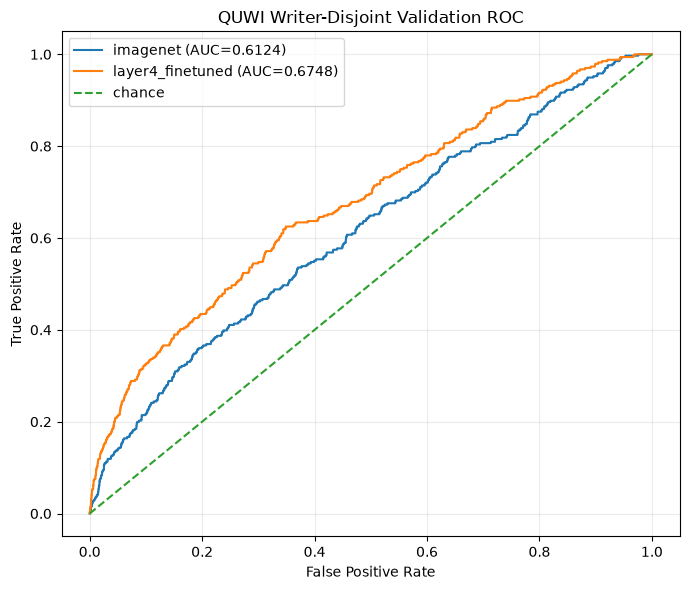

Saved: True
/home/arijit/Documents/handwriting-cross-script-research/reports/writer_disjoint_baseline_verification/validation_aggregate_roc.png


In [15]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)

for model_name, score_column in model_scores.items():
    labels = validation_pairs_df[
        "pair_label"
    ].to_numpy()

    scores = validation_pairs_df[
        score_column
    ].to_numpy()

    fpr, tpr, _ = roc_curve(
        labels,
        scores,
    )

    auc = roc_auc_score(
        labels,
        scores,
    )

    ax.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc:.4f})",
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="chance",
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.set_title(
    "QUWI Writer-Disjoint Validation ROC"
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.tight_layout()

VALIDATION_ROC_PATH = (
    REPORT_DIR
    / "validation_aggregate_roc.png"
)

fig.savefig(
    VALIDATION_ROC_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    VALIDATION_ROC_PATH.exists(),
)

print(
    VALIDATION_ROC_PATH
)

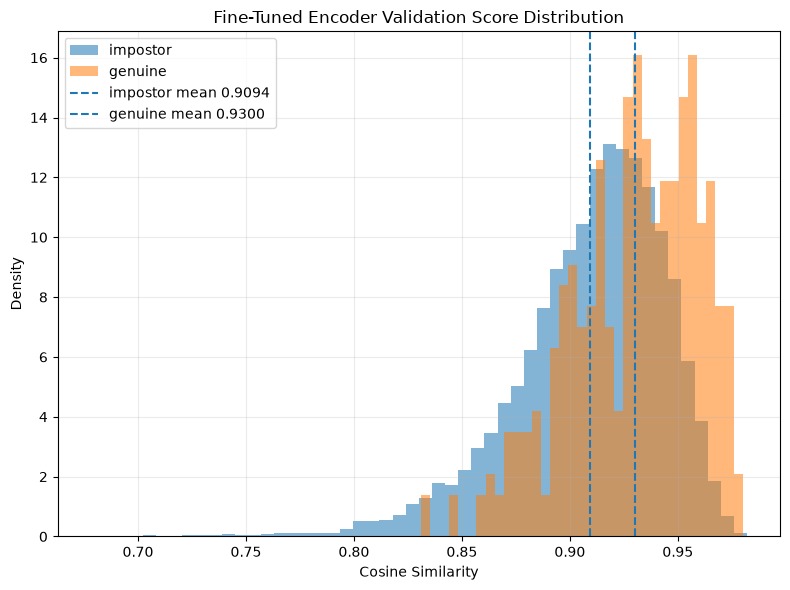

Genuine mean: 0.93
Impostor mean: 0.9094
Mean score gap: 0.0206
Saved: True


In [16]:
finetuned_validation_genuine = (
    validation_pairs_df.loc[
        validation_pairs_df[
            "pair_label"
        ] == 1,
        "finetuned_cosine_score",
    ]
)

finetuned_validation_impostor = (
    validation_pairs_df.loc[
        validation_pairs_df[
            "pair_label"
        ] == 0,
        "finetuned_cosine_score",
    ]
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.hist(
    finetuned_validation_impostor,
    bins=50,
    density=True,
    alpha=0.55,
    label="impostor",
)

ax.hist(
    finetuned_validation_genuine,
    bins=35,
    density=True,
    alpha=0.55,
    label="genuine",
)

ax.axvline(
    finetuned_validation_impostor.mean(),
    linestyle="--",
    label=(
        "impostor mean "
        f"{finetuned_validation_impostor.mean():.4f}"
    ),
)

ax.axvline(
    finetuned_validation_genuine.mean(),
    linestyle="--",
    label=(
        "genuine mean "
        f"{finetuned_validation_genuine.mean():.4f}"
    ),
)

ax.set_xlabel(
    "Cosine Similarity"
)

ax.set_ylabel(
    "Density"
)

ax.set_title(
    "Fine-Tuned Encoder Validation Score Distribution"
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.tight_layout()

VALIDATION_SCORE_PATH = (
    REPORT_DIR
    / "finetuned_validation_score_distribution.png"
)

fig.savefig(
    VALIDATION_SCORE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Genuine mean:",
    round(
        finetuned_validation_genuine.mean(),
        4,
    ),
)

print(
    "Impostor mean:",
    round(
        finetuned_validation_impostor.mean(),
        4,
    ),
)

print(
    "Mean score gap:",
    round(
        finetuned_validation_genuine.mean()
        - finetuned_validation_impostor.mean(),
        4,
    ),
)

print(
    "Saved:",
    VALIDATION_SCORE_PATH.exists(),
)

In [17]:
CACHE_DIR = (
    REPORT_DIR
    / "cache"
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def save_embedding_cache(
    path,
    metadata,
    embeddings,
):
    np.savez_compressed(
        path,
        filenames=metadata[
            "filename"
        ].to_numpy(dtype=str),
        embeddings=embeddings.numpy().astype(
            np.float32
        ),
    )


embedding_cache_paths = {
    "imagenet_validation": (
        CACHE_DIR
        / "imagenet_validation_embeddings.npz"
    ),
    "imagenet_official_test": (
        CACHE_DIR
        / "imagenet_official_test_embeddings.npz"
    ),
    "finetuned_validation": (
        CACHE_DIR
        / "finetuned_validation_embeddings.npz"
    ),
    "finetuned_official_test": (
        CACHE_DIR
        / "finetuned_official_test_embeddings.npz"
    ),
}

save_embedding_cache(
    embedding_cache_paths[
        "imagenet_validation"
    ],
    imagenet_validation_metadata,
    imagenet_validation_embeddings,
)

save_embedding_cache(
    embedding_cache_paths[
        "imagenet_official_test"
    ],
    imagenet_test_metadata,
    imagenet_test_embeddings,
)

save_embedding_cache(
    embedding_cache_paths[
        "finetuned_validation"
    ],
    finetuned_validation_metadata,
    finetuned_validation_embeddings,
)

save_embedding_cache(
    embedding_cache_paths[
        "finetuned_official_test"
    ],
    finetuned_test_metadata,
    finetuned_test_embeddings,
)

score_columns = [
    "pair_id",
    "condition_id",
    "script_relation",
    "text_relation",
    "writer_a",
    "writer_b",
    "pair_label",
    "pair_type",
    "imagenet_cosine_score",
    "finetuned_cosine_score",
]

VALIDATION_SCORE_TABLE_PATH = (
    CACHE_DIR
    / "validation_verification_scores.csv.gz"
)

TEST_SCORE_TABLE_PATH = (
    CACHE_DIR
    / "official_test_verification_scores.csv.gz"
)

validation_pairs_df[
    score_columns
].to_csv(
    VALIDATION_SCORE_TABLE_PATH,
    index=False,
    compression="gzip",
)

test_pairs_df[
    score_columns
].to_csv(
    TEST_SCORE_TABLE_PATH,
    index=False,
    compression="gzip",
)

cache_paths = [
    *embedding_cache_paths.values(),
    VALIDATION_SCORE_TABLE_PATH,
    TEST_SCORE_TABLE_PATH,
]

for path in cache_paths:
    print(
        path.name,
        ":",
        path.exists(),
        "-",
        round(
            path.stat().st_size
            / 1024**2,
            2,
        ),
        "MB",
    )

assert all(
    path.exists()
    for path in cache_paths
)

imagenet_validation_embeddings.npz : True - 0.4 MB
imagenet_official_test_embeddings.npz : True - 1.37 MB
finetuned_validation_embeddings.npz : True - 0.39 MB
finetuned_official_test_embeddings.npz : True - 1.36 MB
validation_verification_scores.csv.gz : True - 0.27 MB
official_test_verification_scores.csv.gz : True - 3.24 MB


In [18]:
METRICS_PATH = (
    REPORT_DIR
    / "verification_metrics.csv"
)

CONDITION_COMPARISON_PATH = (
    REPORT_DIR
    / "condition_model_comparison.csv"
)

SCRIPT_FAMILY_PATH = (
    REPORT_DIR
    / "script_family_summary.csv"
)

FAMILY_COMPARISON_PATH = (
    REPORT_DIR
    / "script_family_model_comparison.csv"
)

GENERALIZATION_PATH = (
    REPORT_DIR
    / "validation_test_condition_consistency.csv"
)

CONDITION_RANKING_PATH = (
    REPORT_DIR
    / "finetuned_condition_ranking.csv"
)

BASELINE_SUMMARY_PATH = (
    REPORT_DIR
    / "baseline_verification_summary.json"
)

verification_metrics_df.to_csv(
    METRICS_PATH,
    index=False,
)

comparison_df.to_csv(
    CONDITION_COMPARISON_PATH,
    index=False,
)

script_family_summary_df.to_csv(
    SCRIPT_FAMILY_PATH,
    index=False,
)

family_comparison_df.to_csv(
    FAMILY_COMPARISON_PATH,
    index=False,
)

condition_generalization_df.to_csv(
    GENERALIZATION_PATH,
    index=False,
)

finetuned_condition_ranking_df.to_csv(
    CONDITION_RANKING_PATH,
    index=False,
)


def aggregate_metrics(
    split_name,
    model_name,
):
    row = verification_metrics_df[
        (
            verification_metrics_df[
                "experiment_split"
            ] == split_name
        )
        & (
            verification_metrics_df[
                "model"
            ] == model_name
        )
        & (
            verification_metrics_df[
                "condition_id"
            ] == "all_conditions"
        )
    ].iloc[0]

    return {
        "roc_auc": float(
            row["roc_auc"]
        ),
        "eer_percent": float(
            row["eer_percent"]
        ),
        "eer_threshold": float(
            row["eer_threshold"]
        ),
        "genuine_mean": float(
            row["genuine_mean"]
        ),
        "impostor_mean": float(
            row["impostor_mean"]
        ),
        "score_gap": float(
            row["score_gap"]
        ),
    }


baseline_summary = {
    "protocol": (
        "QUWI writer-disjoint exhaustive verification"
    ),
    "embedding_dimension": 512,
    "similarity": "cosine",
    "validation_pairs": len(
        validation_pairs_df
    ),
    "official_test_pairs": len(
        test_pairs_df
    ),
    "imagenet": {
        "validation": aggregate_metrics(
            "validation",
            "imagenet",
        ),
        "official_test": aggregate_metrics(
            "official_test",
            "imagenet",
        ),
    },
    "layer4_finetuned": {
        "validation": aggregate_metrics(
            "validation",
            "layer4_finetuned",
        ),
        "official_test": aggregate_metrics(
            "official_test",
            "layer4_finetuned",
        ),
    },
    "fine_tuning_condition_auc_improvements": int(
        (
            comparison_df[
                "auc_change"
            ] > 0
        ).sum()
    ),
    "fine_tuning_condition_eer_improvements": int(
        (
            comparison_df[
                "eer_change_points"
            ] < 0
        ).sum()
    ),
    "finetuned_validation_test_auc_correlation": float(
        condition_generalization_df[
            condition_generalization_df[
                "model"
            ] == "layer4_finetuned"
        ][
            "roc_auc_validation"
        ].corr(
            condition_generalization_df[
                condition_generalization_df[
                    "model"
                ] == "layer4_finetuned"
            ][
                "roc_auc_official_test"
            ]
        )
    ),
}

with BASELINE_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        baseline_summary,
        file,
        indent=2,
    )

saved_result_paths = [
    METRICS_PATH,
    CONDITION_COMPARISON_PATH,
    SCRIPT_FAMILY_PATH,
    FAMILY_COMPARISON_PATH,
    GENERALIZATION_PATH,
    CONDITION_RANKING_PATH,
    BASELINE_SUMMARY_PATH,
    VALIDATION_ROC_PATH,
    VALIDATION_SCORE_PATH,
]

for path in saved_result_paths:
    print(
        path.name,
        ":",
        path.exists(),
    )

print()
print(
    "Fine-tuning AUC improvements:",
    baseline_summary[
        "fine_tuning_condition_auc_improvements"
    ],
    "of 12",
)

print(
    "Fine-tuning EER improvements:",
    baseline_summary[
        "fine_tuning_condition_eer_improvements"
    ],
    "of 12",
)

print(
    "Fine-tuned validation-test AUC correlation:",
    round(
        baseline_summary[
            "finetuned_validation_test_auc_correlation"
        ],
        4,
    ),
)

verification_metrics.csv : True
condition_model_comparison.csv : True
script_family_summary.csv : True
script_family_model_comparison.csv : True
validation_test_condition_consistency.csv : True
finetuned_condition_ranking.csv : True
baseline_verification_summary.json : True
validation_aggregate_roc.png : True
finetuned_validation_score_distribution.png : True

Fine-tuning AUC improvements: 12 of 12
Fine-tuning EER improvements: 11 of 12
Fine-tuned validation-test AUC correlation: 0.9516


## Baseline verification conclusion

This experiment established a writer-disjoint verification baseline on QUWI using cosine similarity between 512-dimensional ResNet-18 embeddings.

Two representations were evaluated:

1. An ImageNet-pretrained ResNet-18 encoder
2. A ResNet-18 encoder whose layer 4 had previously been fine-tuned for writer classification on development-training writers

The validation and official-test writers were completely unseen during supervised model training.

### Aggregate verification performance

On the writer-disjoint validation set, the ImageNet encoder achieved an ROC-AUC of 0.6124 with an EER of 43.15%. The layer-4 fine-tuned encoder improved performance to an ROC-AUC of 0.6748 and an EER of 36.67%.

On the official-test writers, the ImageNet encoder achieved an ROC-AUC of 0.6353 with an EER of 40.17%. The fine-tuned encoder achieved an ROC-AUC of 0.7068 and an EER of 35.15%.

The fine-tuned representation improved ROC-AUC in all 12 split-condition comparisons and reduced EER in 11 of 12 comparisons. This indicates that the supervised representation learned writer-discriminative information that transferred beyond the writers used during training.

### Cross-script generalization

Verification remained substantially harder across scripts than within the same script.

For the fine-tuned encoder, the validation macro ROC-AUC was:

- 0.7350 for within-script verification
- 0.6547 for cross-script verification

This corresponds to a cross-script AUC gap of 0.0803.

On the official-test writers, the corresponding macro ROC-AUC values were:

- 0.7964 for within-script verification
- 0.6725 for cross-script verification

The cross-script gap increased to 0.1238.

These results show that supervised writer discrimination alone does not produce a fully script-invariant representation.

### Condition-level behavior

The strongest condition for the fine-tuned encoder in both evaluation splits was Arabic variable-text versus Arabic same-text:

- Validation ROC-AUC: 0.7545
- Official-test ROC-AUC: 0.8062

The most difficult condition in both splits was Arabic variable-text versus English same-text:

- Validation ROC-AUC: 0.6119
- Official-test ROC-AUC: 0.6304

The ordering of condition difficulty was highly consistent between validation and official-test writers. For the fine-tuned encoder, condition-level validation and official-test ROC-AUC values had a correlation of 0.9516.

The observed condition differences should not yet be interpreted as pure effects of textual content because page identity, fixed-versus-variable text, script, layout, and acquisition characteristics may be partially confounded in QUWI.

### Score separation

For the fine-tuned encoder on validation pairs:

- Mean genuine cosine similarity: 0.9300
- Mean impostor cosine similarity: 0.9094
- Mean separation: 0.0206

Although genuine pairs have higher similarity on average, the two distributions overlap substantially. This explains the relatively high EER and demonstrates that a conventional classification-trained representation is not sufficient for reliable open-set verification.

### Experimental implications

The experiment provides a meaningful baseline for subsequent representation-learning methods.

Future model selection, hyperparameter tuning, augmentation choices, and threshold development will use only the writer-disjoint validation split. The official-test results reported here are treated as descriptive baseline measurements and will not be used to optimize subsequent models.

The next stages should investigate verification-oriented representation learning, including supervised metric learning and self-supervised pretraining, with particular emphasis on reducing the observed cross-script generalization gap.

In [19]:
final_artifacts = {
    "metric_tables": 6,
    "summary_files": 1,
    "figures": 2,
    "embedding_caches": 4,
    "score_caches": 2,
}

print(
    "Validation aggregate AUC:",
    round(
        aggregate_metrics(
            "validation",
            "layer4_finetuned",
        )["roc_auc"],
        4,
    ),
)

print(
    "Validation aggregate EER:",
    round(
        aggregate_metrics(
            "validation",
            "layer4_finetuned",
        )["eer_percent"],
        4,
    ),
    "%",
)

print(
    "Official-test aggregate AUC:",
    round(
        aggregate_metrics(
            "official_test",
            "layer4_finetuned",
        )["roc_auc"],
        4,
    ),
)

print(
    "Official-test aggregate EER:",
    round(
        aggregate_metrics(
            "official_test",
            "layer4_finetuned",
        )["eer_percent"],
        4,
    ),
    "%",
)

print(
    "Condition AUC improvements:",
    baseline_summary[
        "fine_tuning_condition_auc_improvements"
    ],
    "of 12",
)

print(
    "Condition EER improvements:",
    baseline_summary[
        "fine_tuning_condition_eer_improvements"
    ],
    "of 12",
)

print(
    "Saved artifact groups:",
    final_artifacts,
)

print(
    "Notebook 09 complete:",
    True,
)

Validation aggregate AUC: 0.6748
Validation aggregate EER: 36.6721 %
Official-test aggregate AUC: 0.7068
Official-test aggregate EER: 35.1535 %
Condition AUC improvements: 12 of 12
Condition EER improvements: 11 of 12
Saved artifact groups: {'metric_tables': 6, 'summary_files': 1, 'figures': 2, 'embedding_caches': 4, 'score_caches': 2}
Notebook 09 complete: True
